# Loading Dataset

In [288]:
import pandas as pd
import numpy as np

# Load the dataset from csv
full_dataset = pd.read_csv("dataset.csv")

# Drop missing values
full_dataset = full_dataset.dropna()

print(full_dataset.head())



   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   
3  30  Female  28.0       Varanasi    Student                3.0   
4  32  Female  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0   
3            0.0  5.59                 2.0               0.0   
4            0.0  8.13                 3.0               0.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1          5-6 hours       Moderate      BSc   
2  Less than 5 hours        Healthy       BA   
3          7-8

In [289]:
# Display details for each column
for col, dtype in zip(full_dataset.columns, full_dataset.dtypes):
    print(f"{col} ({str(dtype)}): {full_dataset[col].nunique()} unique values")


id (int64): 27898 unique values
Gender (str): 2 unique values
Age (float64): 34 unique values
City (str): 52 unique values
Profession (str): 14 unique values
Academic Pressure (float64): 6 unique values
Work Pressure (float64): 3 unique values
CGPA (float64): 332 unique values
Study Satisfaction (float64): 6 unique values
Job Satisfaction (float64): 5 unique values
Sleep Duration (str): 5 unique values
Dietary Habits (str): 4 unique values
Degree (str): 28 unique values
Have you ever had suicidal thoughts ? (str): 2 unique values
Work/Study Hours (float64): 13 unique values
Financial Stress (float64): 5 unique values
Family History of Mental Illness (str): 2 unique values
Depression (int64): 2 unique values


In [290]:
# Statistical data for each column
print(full_dataset.describe())


                  id           Age  Academic Pressure  Work Pressure  \
count   27898.000000  27898.000000       27898.000000   27898.000000   
mean    70442.953402     25.822174           3.141336       0.000430   
std     40642.015063      4.905651           1.381462       0.043994   
min         2.000000     18.000000           0.000000       0.000000   
25%     35040.750000     21.000000           2.000000       0.000000   
50%     70689.000000     25.000000           3.000000       0.000000   
75%    105824.750000     30.000000           4.000000       0.000000   
max    140699.000000     59.000000           5.000000       5.000000   

               CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  \
count  27898.000000        27898.000000      27898.000000      27898.000000   
mean       7.656160            2.943974          0.000681          7.156570   
std        1.470708            1.361122          0.044397          3.707598   
min        0.000000            0.00

# Data Pre-Processing

In [291]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


# Filter to only students (for consistency)
dataset = full_dataset[full_dataset["Profession"] == "Student"].reset_index(drop=True)

# NOTE: Drop unnecessary variables (This is up for debate!)
# Here's my general reasoning:
# - id: Just a counter, not a relevant value
# - City: This didn't really have any strong effect in testing, and if we want a general model, it doesn't really make sense to include
# - Profession, Work Pressure, Job Satisfaction: Since we're working with students only, there were only like three data points for these values,
#     so I just sorted to only include students, and dropped the profession-based variables
dataset = dataset.drop(columns=["id", "City", "Profession", "Work Pressure", "Job Satisfaction"])

# Add interaction terms
dataset["Pressure_x_Sleep"] = dataset["Academic Pressure"] * dataset["Work/Study Hours"]
dataset["Pressure_x_Stress"] = dataset["Academic Pressure"] * dataset["Financial Stress"]
dataset["Stress_x_Sleep"] = dataset["Financial Stress"] * dataset["Work/Study Hours"]
dataset["Pressure_x_Satisfaction"] = dataset["Academic Pressure"] * dataset["Study Satisfaction"]

interaction_terms = ["Pressure_x_Sleep", "Pressure_x_Stress", "Stress_x_Sleep", "Pressure_x_Satisfaction"]

# Separate the target variable (y)
X = dataset.drop('Depression', axis=1)
y = dataset['Depression']

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Group columns by data type
numeric_features = [
    'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress'
] + interaction_terms
categorical_features = [
    'Gender', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 
    'Family History of Mental Illness'
]

# Column transformer will convert data into usable numeric values for models to use
preprocessor = ColumnTransformer(
    transformers=[
        # Numerical values are already the correct type, so just scale to unit variance
        ('num', StandardScaler(), numeric_features),
        # Categorical variables are one-hot encoded, and then drop the first of each category (so we don't have two variables each for True/False values)
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features.copy())
    ]
)

# Apply the preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original X_train shape: {X_train.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")

Original X_train shape: (22293, 16)
Processed X_train shape: (22293, 47)


# Functions/Tools

## Model Evaluation Tools

In [292]:
from sklearn.metrics import average_precision_score, brier_score_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, matthews_corrcoef, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

def evaluate_model(model, X_test, y_test, name="Model", show_plots=True, threshold=0.5):
    """Evaluate the provided model. Calculates a variety of metrics and (optionally) displays results"""
    metrics = {"Model": name}
    y_proba = None
    y_score = None

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        y_score = y_proba
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_proba)
        metrics["Brier_Score"] = brier_score_loss(y_test, y_proba)
        
        # Apply the threshold
        y_pred = (y_proba >= threshold).astype(int)
    
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_score)
        metrics["Brier_Score"] = None
        
        # Fallback to standard prediction if no probabilities
        y_pred = model.predict(X_test)

    else:
        y_pred = model.predict(X_test)
        metrics["ROC-AUC"] = None
        metrics["Brier_Score"] = None

    # Calculate other prediction metrics
    metrics["Precision"] = precision_score(y_test, y_pred, zero_division=0)
    metrics["Recall"] = recall_score(y_test, y_pred, zero_division=0)
    metrics["F1_Score"] = f1_score(y_test, y_pred, zero_division=0)
    metrics["MCC"] = matthews_corrcoef(y_test, y_pred)
    metrics["AP"] = average_precision_score(y_test, y_score) if y_score is not None else None

    # Display the results
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))
    if metrics["ROC-AUC"] is not None:
        print(f"ROC-AUC: {metrics['ROC-AUC']:.4f}")
    if metrics["Brier_Score"] is not None:
        print(f"Brier Score: {metrics['Brier_Score']:.4f}")
    print(f"MCC: {metrics['MCC']:.4f}")

    if show_plots:
        # Display the confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Not Depressed", "Depressed"]
        )
        disp.plot(cmap="Blues")
        plt.title(f"{name} Confusion Matrix")
        
        if y_proba is not None:
            # Display the ROC curve
            fpr, tpr, _ = roc_curve(y_test, y_proba)

            # Compute Precision-Recall
            precision, recall, _ = precision_recall_curve(y_test, y_proba)
            ap = average_precision_score(y_test, y_proba)

            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            # ROC Curve
            axes[0].plot(fpr, tpr, label=f"AUC = {metrics["ROC-AUC"]:.3f}")
            axes[0].plot([0, 1], [0, 1], linestyle="--")
            axes[0].set_xlabel("False Positive Rate")
            axes[0].set_ylabel("True Positive Rate")
            axes[0].set_title(f"{name} ROC Curve")
            axes[0].legend()
        
            # Precision-Recall Curve
            baseline = sum(y_test) / len(y_test)
            axes[1].plot(recall, precision, label=f"AP = {ap:.3f}")
            axes[1].hlines(baseline, 0, 1, linestyles="--", label="Baseline")
            axes[1].set_xlabel("Recall")
            axes[1].set_ylabel("Precision")
            axes[1].set_title(f"{name} Precision-Recall Curve")
            axes[1].legend()

            plt.tight_layout()

        plt.show()

    return metrics

def show_feature_importance(model, preprocessor, top_n=10):
    feature_names = preprocessor.get_feature_names_out()
    coefficients = model.coef_[0]

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    feature_importance = feature_importance.sort_values(
        by="Coefficient",
        ascending=False
    )

    print(f"\n--- Top {top_n} Features Increasing Risk ---")
    print(feature_importance.head(top_n).to_string(index=False))

    print(f"\n--- Top {top_n} Features Decreasing Risk ---")
    print(feature_importance.tail(top_n).to_string(index=False))

def cross_validate_model(model, X, y, cv=5, scoring="roc_auc", name="Model"):
    """Perform K-fold cross validation, returning the list of scores"""
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    print(f"\n--- {name} {cv}-Fold Cross-Validation ({scoring}) ---")
    print(f"Individual Fold Scores: {['{:.4f}'.format(s) for s in scores]}")
    print(f"Mean Score: {scores.mean():.4f}")
    print(f"Standard Deviation: +/- {scores.std():.4f}")
    
    return scores

def evaluate_sparsity(model) -> int:
    coef = model.coef_[0]
    non_zero = np.sum(coef != 0)
    total = len(coef)
    print(f"Non-zero features: {non_zero}")
    print(f"Total features: {total}")
    print(f"Sparsity: {100 * (1 - non_zero/total):.2f}% features removed")
    return non_zero


import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_gridsearch_param(
    grid_search,
    param_name: str,
    use_log_scale: bool = True,
    selected_value: float = None
):
    """Plot score vs. a hyperparameter (to select best value for a minimal model)"""
    results = pd.DataFrame(grid_search.cv_results_)

    param_col = f"param_{param_name}"
    if param_col not in results:
        raise ValueError(f"Parameter '{param_name}' not found.")

    x = results[param_col].astype(float)
    y = results["mean_test_score"]
    std = results["std_test_score"]

    # Sort for clean plotting
    order = np.argsort(x)
    x, y, std = x.iloc[order], y.iloc[order], std.iloc[order]

    # Best point
    best_idx = y.idxmax()
    best_x = results.loc[best_idx, param_col]
    best_y = results.loc[best_idx, "mean_test_score"]
    best_std = results.loc[best_idx, "std_test_score"]

    upper = best_y + best_std
    lower = best_y - best_std

    plt.figure()

    # Main curve
    plt.plot(x, y, marker="o", label="Mean CV Score")

    # Highlight best point
    plt.scatter(best_x, best_y, color="red", zorder=3, label="Best")

    # Horizontal std band
    plt.axhspan(lower, upper, alpha=0.15, label="±1 std (best)")

    if selected_value is not None:
        selected_value = float(selected_value)
        selected_y = np.interp(selected_value, x, y)  # approximate y-position

        plt.scatter(
            selected_value,
            selected_y,
            color="green",
            s=100,
            zorder=4,
            label=f"Selected {param_name} = {selected_value:.4f}"
        )
        plt.axvline(selected_value, color="red", linestyle="--", alpha=0.5)

    plt.xlabel(param_name)
    plt.ylabel("Mean Test Score")
    plt.title(f"{param_name} vs Cross-Validated Score")
    plt.grid(True)

    if use_log_scale:
        plt.xscale("log")

    plt.legend()
    plt.tight_layout()
    plt.show()


In [293]:
def find_best_threshold(y_true, y_proba, target_recall=None, target_precision=None):
    """Find threshold based on target recall or precision"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    thresholds = np.append(thresholds, 1.0)  # Fix array size difference

    # Target recall
    if target_recall is not None:
        valid_idx = np.where(recall >= target_recall)[0]
        if len(valid_idx) == 0:
            return None
        
        best_idx = valid_idx[np.argmax(precision[valid_idx])]

    # Target precision
    elif target_precision is not None:
        valid_idx = np.where(precision >= target_precision)[0]
        if len(valid_idx) == 0:
            return None
        
        best_idx = valid_idx[np.argmax(recall[valid_idx])]

    else:
        raise ValueError("Provide either target_recall or target_precision")

    return {
        "threshold": thresholds[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx]
    }

# Logistic Regression

## Standard (All predictors)


--- Standard LR 5-Fold Cross-Validation (roc_auc) ---
Individual Fold Scores: ['0.9208', '0.9258', '0.9226', '0.9167', '0.9196']
Mean Score: 0.9211
Standard Deviation: +/- 0.0030

--- Full (47 features) Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.84      0.82      2312
           1       0.88      0.84      0.86      3262

    accuracy                           0.84      5574
   macro avg       0.84      0.84      0.84      5574
weighted avg       0.84      0.84      0.84      5574

ROC-AUC: 0.9205
Brier Score: 0.1124
MCC: 0.6785


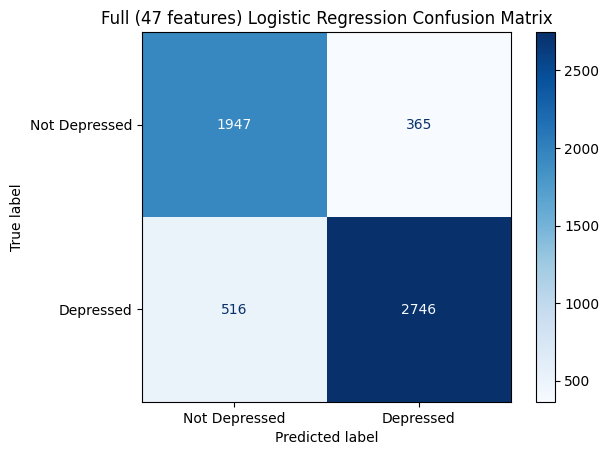

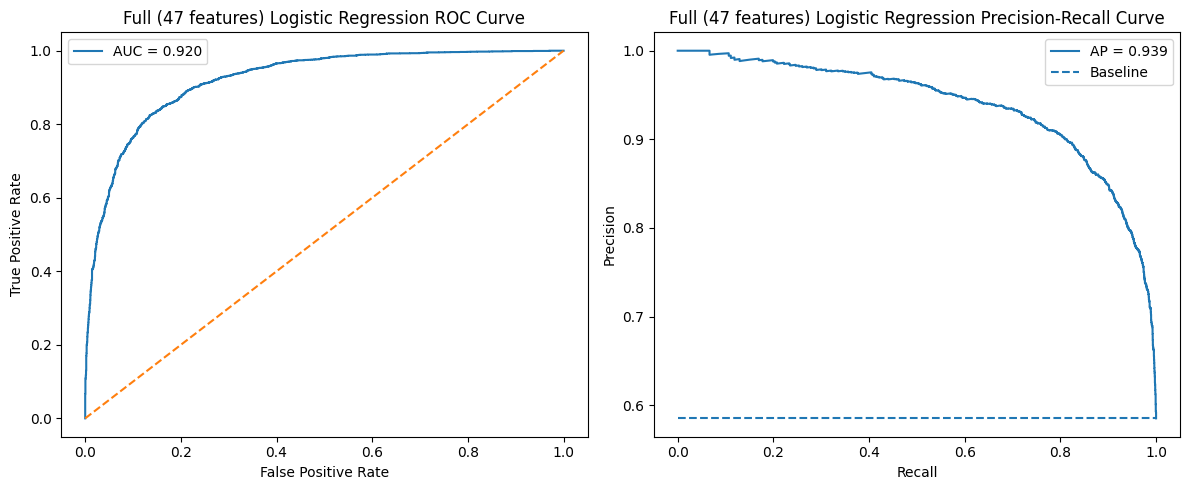


--- Top 10 Features Increasing Risk ---
                                       Feature  Coefficient
cat__Have you ever had suicidal thoughts ?_Yes     2.526278
                        num__Academic Pressure     1.315490
                 cat__Dietary Habits_Unhealthy     1.097851
                         num__Financial Stress     0.847918
                  cat__Dietary Habits_Moderate     0.484048
                         num__Work/Study Hours     0.407458
         cat__Sleep Duration_Less than 5 hours     0.338109
                               cat__Degree_LLB     0.244887
     cat__Family History of Mental Illness_Yes     0.240014
                               cat__Degree_LLM     0.191056

--- Top 10 Features Decreasing Risk ---
                              Feature  Coefficient
              num__Study Satisfaction    -0.202117
                      cat__Degree_MBA    -0.225770
cat__Sleep Duration_More than 8 hours    -0.241104
                       cat__Degree_BA    -0.246168
   

In [294]:
from sklearn.linear_model import LogisticRegression

# Build the logistic regression model ("balanced" means classes are given equal weight)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train the model
log_reg.fit(X_train_processed, y_train)

# Do cross-validation to check consistency
cv_scores = cross_validate_model(log_reg, X_train_processed, y_train, cv=5, name="Standard LR")

# Evaluate the model
evaluate_model(log_reg, X_test_processed, y_test, f"Full ({len(log_reg.coef_[0])} features) Logistic Regression")

# Rank features by importance
show_feature_importance(log_reg, preprocessor)


## Sparse (Using Lasso Regression)

Non-zero features: 14
Total features: 47
Sparsity: 70.21% features removed

--- Sparse (14 features) LR 5-Fold Cross-Validation (roc_auc) ---
Individual Fold Scores: ['0.9206', '0.9259', '0.9218', '0.9159', '0.9198']
Mean Score: 0.9208
Standard Deviation: +/- 0.0032
Threshold Details: (Threshold = 0.3749 | Precision = 0.8490 | Recall = 0.9001

--- Sparse (14 features) Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.77      0.81      2312
           1       0.85      0.90      0.87      3262

    accuracy                           0.85      5574
   macro avg       0.85      0.84      0.84      5574
weighted avg       0.85      0.85      0.85      5574

ROC-AUC: 0.9207
Brier Score: 0.1122
MCC: 0.6846


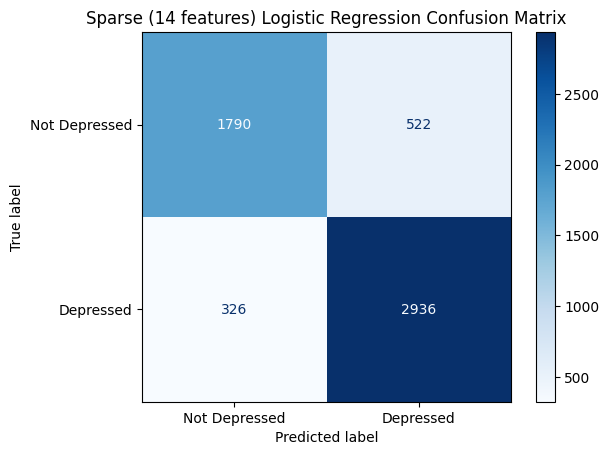

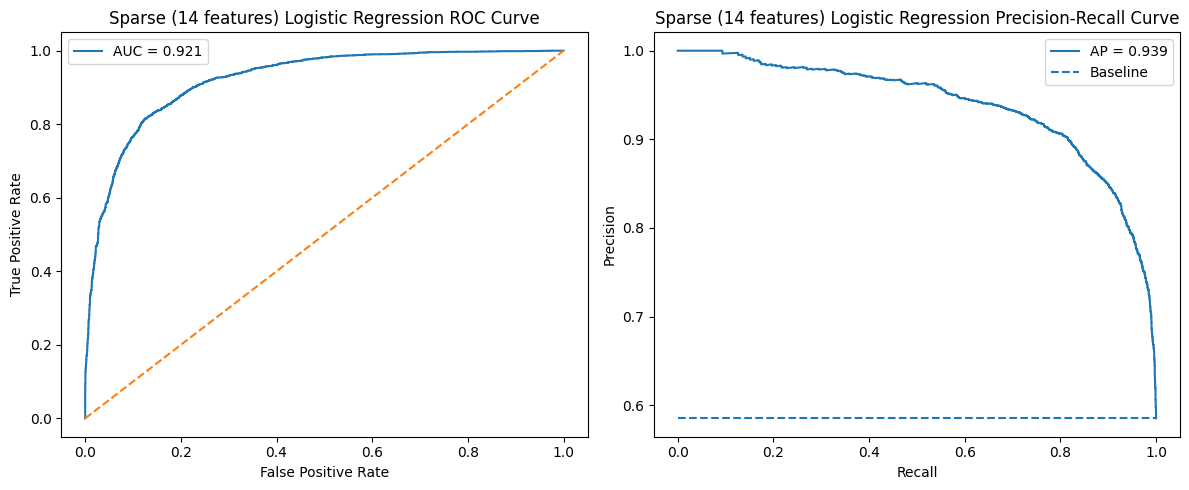


--- Top 10 Features Increasing Risk ---
                                       Feature  Coefficient
cat__Have you ever had suicidal thoughts ?_Yes     2.397455
                        num__Academic Pressure     1.037546
                 cat__Dietary Habits_Unhealthy     0.881208
                         num__Financial Stress     0.713971
                  cat__Dietary Habits_Moderate     0.295051
                         num__Work/Study Hours     0.287949
         cat__Sleep Duration_Less than 5 hours     0.262799
     cat__Family History of Mental Illness_Yes     0.155603
                         num__Pressure_x_Sleep     0.101996
                           num__Stress_x_Sleep     0.069785

--- Top 10 Features Decreasing Risk ---
                              Feature  Coefficient
                  cat__Degree_M.Pharm     0.000000
                   cat__Degree_M.Tech     0.000000
                      cat__Degree_MSc     0.000000
                      cat__Degree_MHM     0.000000
   

In [ ]:
from sklearn.model_selection import GridSearchCV

# Tuning flag - If performance is bad, disable this! (model will use pre-tuned C value from my testing)
TUNE_C = True
DEFAULT_C = 0.02

if TUNE_C:
    # Build the base LR model to evaluate C values
    base_log_reg = LogisticRegression(
        l1_ratio=1.0,
        solver="saga",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    # Test all values of C using 5-fold cross validation (ROC-AUC) to evaluate
    hyper_parameter_grid = {
        'C': np.linspace(0.001, 0.5, 50)
    }
    grid_search = GridSearchCV(
        estimator=base_log_reg,
        param_grid=hyper_parameter_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    print("Running Hyperparameter Tuning...")
    grid_search.fit(X_train_processed, y_train)

    # Keep the best model
    results = pd.DataFrame(grid_search.cv_results_)
    best_index = results['mean_test_score'].idxmax()
    best_score = results.loc[best_index, 'mean_test_score']

    practical_margin = 0.001  # Acceptable offset from the absolute minimum to search for simpler models
    acceptable_threshold = best_score - practical_margin

    # Choose the simplest model within the acceptable threshold
    good_models = results[results["mean_test_score"] >= acceptable_threshold]
    optimal_C = good_models['param_C'].astype(float).min()
    print(f"Optimal 'C' within margin: {optimal_C:.4f}")
    plot_gridsearch_param(grid_search, "C", selected_value=optimal_C, use_log_scale=False)
else:
    # If tuning is disabled, use value from testing
    optimal_C = DEFAULT_C

# Now, train a model with the optimal C
log_reg_sparse = LogisticRegression(
    l1_ratio=1.0, 
    solver="saga",
    C=optimal_C,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
log_reg_sparse.fit(X_train_processed, y_train)

# Evaluate sparsity after Lasso
num_features = evaluate_sparsity(log_reg_sparse)

# Do cross-validation to check consistency
cv_scores = cross_validate_model(log_reg_sparse, X_train_processed, y_train, cv=5, name=f"Sparse ({num_features} features) LR")

# Find the best threshold for evaluation (Used to weight TP/FN)
y_proba_test = log_reg_sparse.predict_proba(X_test_processed)[:, 1]
threshold_result = find_best_threshold(y_test, y_proba_test, target_recall=0.90)  # Catch 90% of true positives (avoid false negatives)
print(f"Threshold Details: (Threshold = {threshold_result["threshold"]:.4f} | Precision = {threshold_result["precision"]:.4f} | Recall = {threshold_result["recall"]:.4f}")

# Evaluate the model
evaluate_model(log_reg_sparse, X_test_processed, y_test, f"Sparse ({num_features} features) Logistic Regression", threshold=threshold_result["threshold"])

# Rank features by importance
show_feature_importance(log_reg_sparse, preprocessor)

## Without Suicide Indication (Avoiding leakage)
Because suicide is so closely aligned with depression, including it could be considered data leakage ("Are you suicidal?" is basically the same as "Are you depressed?")

Below is the same logistic regression model trained without the suicide survey point

In [296]:
# Also split a dataset without the suicidal tendency variable (could be leaking?)
categorical_features_no_suicide = categorical_features.copy()
categorical_features_no_suicide.remove('Have you ever had suicidal thoughts ?')

X_train_no_suicide = X_train.drop(columns=["Have you ever had suicidal thoughts ?"])
X_test_no_suicide = X_test.drop(columns=["Have you ever had suicidal thoughts ?"])

preprocessor_no_suicide = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features_no_suicide)
    ]
)

X_train_processed_no_suicide = preprocessor_no_suicide.fit_transform(X_train_no_suicide)
X_test_processed_no_suicide = preprocessor_no_suicide.transform(X_test_no_suicide)

Non-zero features: 15
Total features: 46
Sparsity: 67.39% features removed

--- Sparse (15 features) LR (No Suicide) 5-Fold Cross-Validation (roc_auc) ---
Individual Fold Scores: ['0.8731', '0.8716', '0.8703', '0.8648', '0.8761']
Mean Score: 0.8712
Standard Deviation: +/- 0.0037
Threshold Details: (Threshold = 0.3248 | Precision = 0.7850 | Recall = 0.9010

--- Sparse (15 features) LR (No Suicide) Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.65      0.73      2312
           1       0.78      0.90      0.84      3262

    accuracy                           0.80      5574
   macro avg       0.80      0.78      0.78      5574
weighted avg       0.80      0.80      0.79      5574

ROC-AUC: 0.8741
Brier Score: 0.1438
MCC: 0.5800


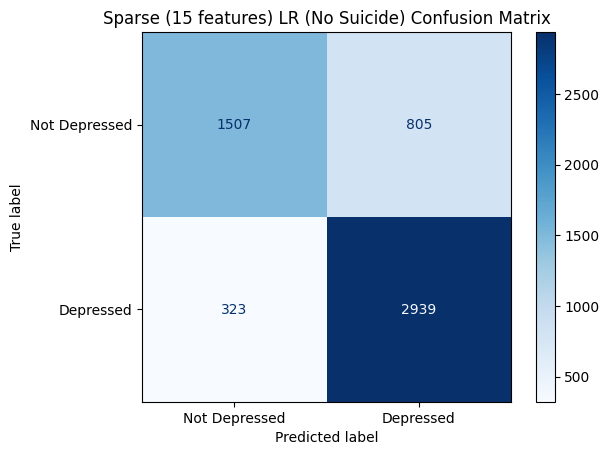

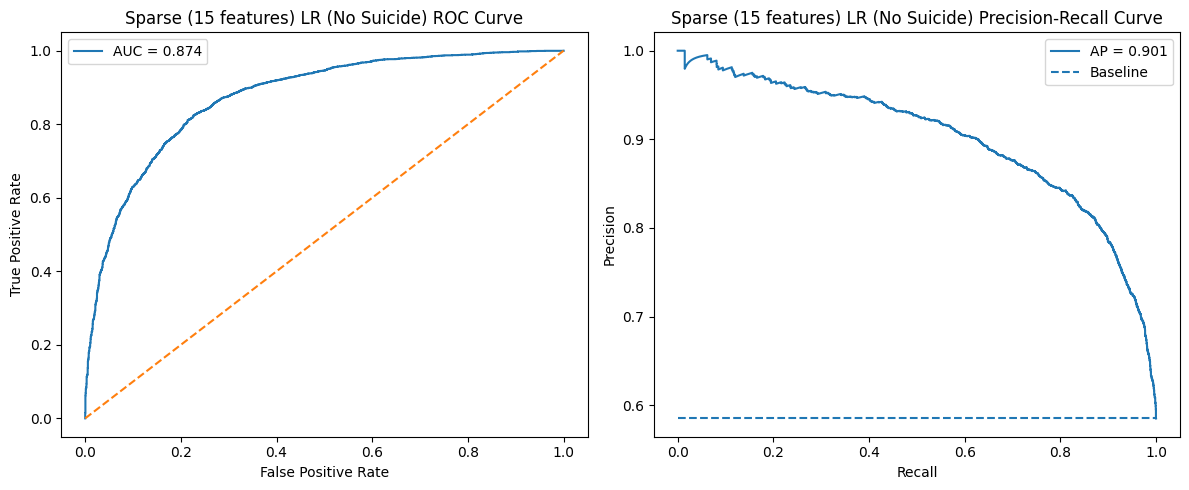


--- Top 10 Features Increasing Risk ---
                                  Feature  Coefficient
                   num__Academic Pressure     1.136587
            cat__Dietary Habits_Unhealthy     0.920781
                    num__Financial Stress     0.732481
             cat__Dietary Habits_Moderate     0.357102
                    num__Work/Study Hours     0.310472
    cat__Sleep Duration_Less than 5 hours     0.274804
cat__Family History of Mental Illness_Yes     0.174731
                      num__Stress_x_Sleep     0.095333
                                num__CGPA     0.057577
                    num__Pressure_x_Sleep     0.055699

--- Top 10 Features Decreasing Risk ---
                              Feature  Coefficient
                      cat__Degree_MBA     0.000000
                  cat__Degree_M.Pharm     0.000000
                   cat__Degree_Others     0.000000
                      cat__Degree_MSc     0.000000
                      cat__Degree_PhD     0.000000
       

In [ ]:
TUNE_C = True
DEFAULT_C = 0.02

if TUNE_C:
    # Build the base LR model to evaluate C values
    base_log_reg = LogisticRegression(
        l1_ratio=1.0,
        solver="saga",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

    # Test all values of C using 5-fold cross validation (ROC-AUC) to evaluate
    hyper_parameter_grid = {
        'C': np.linspace(0.001, 0.5, 50)
    }
    grid_search = GridSearchCV(
        estimator=base_log_reg,
        param_grid=hyper_parameter_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    print("Running Hyperparameter Tuning...")
    grid_search.fit(X_train_processed_no_suicide, y_train)

    # Keep the best model
    results = pd.DataFrame(grid_search.cv_results_)
    best_index = results['mean_test_score'].idxmax()
    best_score = results.loc[best_index, 'mean_test_score']

    practical_margin = 0.001  # Acceptable offset from the absolute minimum to search for simpler models
    acceptable_threshold = best_score - practical_margin

    # Choose the simplest model within the acceptable threshold
    good_models = results[results["mean_test_score"] >= acceptable_threshold]
    optimal_C = good_models['param_C'].astype(float).min()
    print(f"Optimal 'C' within margin: {optimal_C:.4f}")
    plot_gridsearch_param(grid_search, "C", selected_value=optimal_C, use_log_scale=False)
    
else:
    # If tuning is disabled, use value from testing
    optimal_C = DEFAULT_C

# Now, train a model with the optimal C
log_reg_no_suicide = LogisticRegression(
    l1_ratio=1.0,
    solver="saga",
    C=optimal_C,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
log_reg_no_suicide.fit(X_train_processed_no_suicide, y_train)

# Evaluate sparsity after Lasso
num_features = evaluate_sparsity(log_reg_no_suicide)

# Do cross-validation to check consistency
cv_scores = cross_validate_model(log_reg_no_suicide, X_train_processed_no_suicide, y_train, cv=5, name=f"Sparse ({num_features} features) LR (No Suicide)")

# Find the best threshold for evaluation (Used to weight TP/FN)
y_proba_test = log_reg_no_suicide.predict_proba(X_test_processed_no_suicide)[:, 1]
threshold_result = find_best_threshold(y_test, y_proba_test, target_recall=0.90)  # Catch 90% of true positives (avoid false negatives)
print(f"Threshold Details: (Threshold = {threshold_result["threshold"]:.4f} | Precision = {threshold_result["precision"]:.4f} | Recall = {threshold_result["recall"]:.4f}")

# Evaluate the model
evaluate_model(log_reg_no_suicide, X_test_processed_no_suicide, y_test, f"Sparse ({num_features} features) LR (No Suicide)", threshold=threshold_result["threshold"])

# Rank features by importance
show_feature_importance(log_reg_no_suicide, preprocessor_no_suicide)